# WSmart+ Route — Single-Day Optimization

This notebook performs a single-day collection route optimization using real bin state data
and the Candaval depot distance matrix.

**Data sources (choose one via `DATA_SOURCE_TYPE` in Section 1):**
- **HTML / URL** — crawl a WSmart+ dashboard export directly (e.g. `dashboard_riomaior_20260622_104546.html` or a live URL)
- **CSV** — a crawler-exported CSV (`logic.src.data.web.to_csv`)
- **XLSX** — the original EVOX spreadsheet (`Análise_Dashboard_EVOX_14052026.xlsx`, sheet `02Junho`)

**Distance matrix:** `data/wsr_simulator/distance_matrix/Matriz_distancia_258contentores_DepotCandaval.xlsx`

**Pipeline:**
1. Load bin states (HTML/CSV/XLSX) and distance matrix
2. Cross-filter bins to the distance-matrix coverage
3. Select bins with **LookaheadMustGo** strategy (overflow today + before next collection visit)
4. Solve multi-trip CVRP with **PG-CLNS** (Pheromone-Guided Cooperative Large Neighborhood Search)
5. Automatic multi-trip splitting when collected kg exceeds vehicle capacity
6. Visualise per-trip routes and report KPIs

---
## 0 · Notebook Setup

In [1]:
from tutorials.notebook_setup import setup_google_colab, setup_home_directory

NOTEBOOK_NAME = 'single_day_optimization'
home_dir = setup_home_directory(NOTEBOOK_NAME)
IN_COLAB, gdrive, gfiles = setup_google_colab(NOTEBOOK_NAME)

Setup completed - added home_dir to system path: ~/Repositories/WSmart-Route
Google Colab libraries not found. Are you running in a Colab notebook?


In [2]:
import os
import time
from typing import Dict, List, Optional, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Circular-import primers — must appear before any logic.src.pipeline imports
import logic.src.data.datasets  # noqa: F401
from logic.src.pipeline.simulations.actions.base import _flatten_config  # noqa: F401

from logic.src.interfaces.context.selection_context import SelectionContext
from logic.src.policies.mandatory_selection.selection_lookahead import LookaheadSelection
from logic.src.policies.route_construction.meta_heuristics.pheromone_guided_cooperative_large_neighborhood_search.params import (
    ACOParams,
    LNSParams,
    PGCLNSParams,
)
from logic.src.policies.route_construction.meta_heuristics.pheromone_guided_cooperative_large_neighborhood_search.pg_clns import (
    PGCLNSSolver,
)
from logic.src.policies.route_construction.other_algorithms.travelling_salesman_problem.tsp import get_route_cost

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

~/Repositories/WSmart-Route/.venv/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: ~/Repositories/WSmart-Route/.venv/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  import torch_geometric.typing
~/Repositories/WSmart-Route/.venv/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: ~/Repositories/WSmart-Route/.venv/lib/python3.10/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  import torch_geometric.typing


Set parameter Username


Set parameter Username


Set parameter LicenseID to value 2793995


Set parameter LicenseID to value 2793995


Academic license - for non-commercial use only - expires 2027-03-18


Academic license - for non-commercial use only - expires 2027-03-18


---
## 1 · Configuration

In [3]:
# ── Data source ───────────────────────────────────────────────────────────────
# "html" : crawl a local dashboard HTML file  (set HTML_SOURCE below)
# "url"  : crawl a live dashboard URL         (set HTML_SOURCE to the URL)
# "csv"  : load a crawler-exported CSV        (set DATASET_PATH below)
# "xlsx" : load the original EVOX spreadsheet (set DATASET_PATH + DATASET_SHEET)
DATA_SOURCE_TYPE = "html"

# HTML / URL source path (used when DATA_SOURCE_TYPE is "html" or "url")
HTML_SOURCE = os.path.join(
    home_dir, 'data', 'wsr_simulator', 'raw_extract',
    'dashboard_riomaior_20260622_104546.html',
)

# Spreadsheet / CSV source (used when DATA_SOURCE_TYPE is "xlsx" or "csv")
DATASET_PATH = os.path.join(
    home_dir, 'data', 'wsr_simulator', 'datasets',
    'Análise_Dashboard_EVOX_14052026.xlsx',
)
DATASET_SHEET = '02Junho'   # only used for DATA_SOURCE_TYPE == "xlsx"

# ── Distance matrix ───────────────────────────────────────────────────────────
DIST_MATRIX_PATH = os.path.join(
    home_dir, 'data', 'wsr_simulator', 'distance_matrix',
    'Contentores197_riomaior_papel.xlsx',
)
DIST_MATRIX_SHEET = 'matrizdistancias'

# ── Economic parameters ───────────────────────────────────────────────────────
VEHICLE_CAPACITY  = 3500.0  # kg per trip
REVENUE_PER_KG    = 1.0     # € / kg collected
COST_PER_KM       = 1.0     # € / km driven
SEED              = 42

# ── PG-CLNS solver parameters ─────────────────────────────────────────────────
PGCLNS_PARAMS = PGCLNSParams(
    population_size  = 10,
    max_iterations   = 50,
    replacement_rate = 0.2,
    time_limit       = 60.0,
    aco=ACOParams(
        n_ants                 = 20,
        k_sparse               = 15,
        alpha                  = 1.0,
        beta                   = 2.0,
        rho                    = 0.1,
        q0                     = 0.9,
        max_iterations         = 1,
        time_limit             = 30.0,
        local_search           = False,
        local_search_iterations= 0,
        elitist_weight         = 1.0,
    ),
    lns=LNSParams(
        max_iterations  = 200,
        start_temp      = 100.0,
        cooling_rate    = 0.995,
        reaction_factor = 0.5,
        min_removal     = 1,
        max_removal_pct = 0.3,
        time_limit      = 30.0,
    ),
)

print(f'Data source      : {DATA_SOURCE_TYPE.upper()}')
print(f'Distance matrix  : {os.path.basename(DIST_MATRIX_PATH)}')
print(f'Vehicle capacity : {VEHICLE_CAPACITY} kg/trip')
print(f'Revenue/Cost     : €{REVENUE_PER_KG:.2f}/kg   €{COST_PER_KM:.2f}/km')
print(f'PG-CLNS          : pop={PGCLNS_PARAMS.population_size}, '
      f'iters={PGCLNS_PARAMS.max_iterations}, '
      f'time_limit={PGCLNS_PARAMS.time_limit}s')

Data source      : HTML
Distance matrix  : Contentores197_riomaior_papel.xlsx
Vehicle capacity : 3500.0 kg/trip
Revenue/Cost     : €1.00/kg   €1.00/km
PG-CLNS          : pop=10, iters=50, time_limit=60.0s


---
## 2 · Load Data

In [4]:
# ── Bin state data ────────────────────────────────────────────────────────────

def _normalize_crawler_df(raw: pd.DataFrame) -> pd.DataFrame:
    """Convert a crawler extract_dataframe() result into the canonical bins_df schema."""
    _fill_pct = raw['Fill_Pct'].values          # 0–100
    _rate_pct = raw['Acum_Rate_Pct'].values     # %/day
    _days_ov  = np.where(
        _rate_pct > 0,
        (100.0 - _fill_pct) / _rate_pct,
        np.inf,
    ).clip(0, 999)
    return pd.DataFrame({
        'bin_id'             : raw['ID'].astype(int),
        'fill_current'       : _fill_pct / 100.0,
        'fill_mean'          : raw['Fill_Avg_Pct'] / 100.0,
        'accum_rate_pct_day' : _rate_pct,
        'volume_kg'          : raw['Volume_kg'],
        'kg_to_collect'      : raw['Volume_kg'],
        'n_containers'       : raw['N_Containers'].astype(int),
        'container_vol_m3'   : np.nan,
        'lat'                : raw['Lat'],
        'lon'                : raw['Lng'],
        'fill_rate_per_day'  : _rate_pct / 100.0,
        'days_until_overflow': _days_ov,
        'fill_day1'          : ((_fill_pct + _rate_pct * 1) / 100).clip(0, 1),
        'fill_day2'          : ((_fill_pct + _rate_pct * 2) / 100).clip(0, 1),
        'fill_day3'          : ((_fill_pct + _rate_pct * 3) / 100).clip(0, 1),
        'fill_day4'          : ((_fill_pct + _rate_pct * 4) / 100).clip(0, 1),
        'visited'            : np.nan,
        'must_go_flag'       : np.nan,
    }).reset_index(drop=True)


if DATA_SOURCE_TYPE in ("html", "url"):
    from logic.src.data.web.dashboard_crawler import extract_dataframe
    _raw = extract_dataframe(HTML_SOURCE)
    bins_df = _normalize_crawler_df(_raw)
    _source_label = os.path.basename(HTML_SOURCE)

elif DATA_SOURCE_TYPE == "csv":
    _raw = pd.read_csv(DATASET_PATH)
    bins_df = _normalize_crawler_df(_raw)
    _source_label = os.path.basename(DATASET_PATH)

elif DATA_SOURCE_TYPE == "xlsx":
    raw = pd.read_excel(DATASET_PATH, sheet_name=DATASET_SHEET, header=1)
    raw = raw.dropna(subset=['Local'])
    raw = raw[raw['Local'].apply(lambda x: str(x).replace('.0', '').isdigit())].copy()
    raw['bin_id'] = raw['Local'].astype(int)

    col_rename = {
        'Local'                   : 'bin_id_raw',
        '% vol. atual'            : 'fill_current',
        '% vol. média'            : 'fill_mean',
        'Acum. (%/dia)'           : 'accum_rate_pct_day',
        'Volume (kg)'             : 'volume_kg',
        'Nº Cont.'                : 'n_containers',
        'Volume do contentor (m3)': 'container_vol_m3',
        'Latitude'                : 'lat',
        'Longitude'               : 'lon',
        'Foi visitado?'           : 'visited',
        'Kg Visitados'            : 'kg_visited',
        'Kg a recolher'           : 'kg_to_collect',
        '%/Dia'                   : 'fill_rate_per_day',
        'Dias até Overflow'       : 'days_until_overflow',
        'Dia 1'                   : 'fill_day1',
        'Dia 2'                   : 'fill_day2',
        'Dia 3'                   : 'fill_day3',
        'Dia 4'                   : 'fill_day4',
        74                        : 'must_go_flag',
    }
    bins_df = raw.rename(columns=col_rename)[[
        'bin_id', 'fill_current', 'fill_mean', 'accum_rate_pct_day',
        'volume_kg', 'n_containers', 'container_vol_m3',
        'lat', 'lon', 'visited', 'kg_to_collect',
        'fill_rate_per_day', 'days_until_overflow', 'must_go_flag',
        'fill_day1', 'fill_day2', 'fill_day3', 'fill_day4',
    ]].reset_index(drop=True)
    _source_label = f'{DATASET_SHEET} · {os.path.basename(DATASET_PATH)}'

else:
    raise ValueError(
        f"Unknown DATA_SOURCE_TYPE: {DATA_SOURCE_TYPE!r}. "
        "Use 'html', 'url', 'xlsx', or 'csv'."
    )

print(f'Source                : {_source_label}')
print(f'Bins loaded           : {len(bins_df)}')
print(f'Mean fill level       : {bins_df["fill_current"].mean():.1%}')
print(f'Mean accum rate       : {bins_df["accum_rate_pct_day"].mean():.2f} %/day')
bins_df.head()

Source                : dashboard_riomaior_20260622_104546.html
Bins loaded           : 197
Mean fill level       : 55.1%
Mean accum rate       : 34.05 %/day


,bin_id,fill_current,fill_mean,accum_rate_pct_day,volume_kg,kg_to_collect,n_containers,container_vol_m3,lat,lon,fill_rate_per_day,days_until_overflow,fill_day1,fill_day2,fill_day3,fill_day4,visited,must_go_flag
0,350,1.0,1.0,35.0,80.0,80.0,2,NaN,39.281639,-8.851742,0.35,0.0,1.0,1.0,1.0,1.0,NaN,NaN
1,353,1.0,1.0,35.0,40.0,40.0,1,NaN,39.294610,-8.822395,0.35,0.0,1.0,1.0,1.0,1.0,NaN,NaN
2,362,1.0,1.0,35.0,40.0,40.0,1,NaN,39.373414,-8.891544,0.35,0.0,1.0,1.0,1.0,1.0,NaN,NaN
3,365,1.0,1.0,35.0,40.0,40.0,1,NaN,39.421536,-8.916290,0.35,0.0,1.0,1.0,1.0,1.0,NaN,NaN
4,366,1.0,1.0,35.0,40.0,40.0,1,NaN,39.390875,-8.927229,0.35,0.0,1.0,1.0,1.0,1.0,NaN,NaN


In [5]:
# ── Distance matrix ──────────────────────────────────────────────────────────
# Index and columns are bin IDs; 0 = Candaval depot
dm_raw = pd.read_excel(
    DIST_MATRIX_PATH, sheet_name=DIST_MATRIX_SHEET, index_col=0
)
dm_raw.columns = dm_raw.columns.astype(int)
dm_raw.index   = dm_raw.index.astype(int)

# Positional list: position 0 → depot (ID 0), position i → bin ID dm_ids[i]
dm_ids = list(dm_raw.index)           # list of IDs in row order
id_to_pos: Dict[int, int] = {bid: pos for pos, bid in enumerate(dm_ids)}
dm_np = dm_raw.values.astype(float)   # shape (259, 259)

# Fill NaN entries (missing road distances) with the 95th-percentile finite distance
nan_mask = np.isnan(dm_np)
if nan_mask.any():
    fill_val = float(np.nanpercentile(dm_np, 95))
    dm_np[nan_mask] = fill_val
    print(f'Filled {nan_mask.sum()} NaN entries with {fill_val:.2f} km (95th-pct fallback)')

lat_lon_raw = pd.read_excel(
    DIST_MATRIX_PATH, sheet_name='LatLong'
).rename(columns={'id_contentor': 'bin_id', 'Latitude': 'lat_dm', 'Longitude': 'lon_dm'})

# Lat: 39.188744520260286; Lon: -9.1485128705079
depot_row = lat_lon_raw[lat_lon_raw['bin_id'] == 0].iloc[0]
depot_lat, depot_lon = float(depot_row['lat_dm']), float(depot_row['lon_dm'])

print(f'Distance matrix shape : {dm_np.shape}  (includes depot at position 0)')
print(f'Depot (ID=0) coords   : lat={depot_lat:.6f}, lon={depot_lon:.6f}')
print(f'Min / Max distance    : {dm_np[dm_np > 0].min():.2f} / {dm_np.max():.2f} km')

Distance matrix shape : (198, 198)  (includes depot at position 0)
Depot (ID=0) coords   : lat=39.188769, lon=-9.148471
Min / Max distance    : 0.06 / 67.77 km


In [6]:
# ── Handle bins not covered by the distance matrix ────────────────────────────
_dm_bin_ids  = set(dm_raw.index.astype(int)) - {0}
_mask_in_dm  = bins_df['bin_id'].isin(_dm_bin_ids)
_missing_ids = sorted(bins_df.loc[~_mask_in_dm, 'bin_id'].tolist())
_n_missing   = len(_missing_ids)

if _n_missing == 0:
    print(f'All {len(bins_df)} bins are covered by the distance matrix.')
else:
    print(f'WARNING: {_n_missing} bin(s) in the dataset have no entry in the distance matrix:')
    print(f'   IDs: {_missing_ids}')
    print()
    print('How do you want to proceed?')
    print()
    print('  [1] Generate a new Haversine distance matrix for ALL nodes')
    print('      Straight-line km — no external API needed, computed in seconds.')
    print('      The new matrix is saved to distance_matrix/ for future reuse.')
    print('      Note: Haversine km < road km, so cost/profit figures will differ')
    print('      from a road-network matrix.')
    print()
    print('  [2] Skip the missing bins and continue without them')
    print('      The simulation runs on the bins that DO have distance data.')
    print()

    _choice = ''
    while _choice not in ('1', '2'):
        _choice = input('Your choice [1 / 2]: ').strip()
        if _choice not in ('1', '2'):
            print(f'  Invalid input "{_choice}". Please enter 1 or 2.')

    if _choice == '1':
        from logic.src.data.network import HaversineStrategy

        # Build a coords DataFrame with a clean RangeIndex so that
        # IterativeDistanceStrategy.calculate() indexes the matrix correctly.
        _hsd_ids  = [0]              + list(bins_df['bin_id'])
        _hsd_lats = [depot_lat]      + list(bins_df['lat'])
        _hsd_lngs = [depot_lon]      + list(bins_df['lon'])
        _hsd_coords = pd.DataFrame({'Lat': _hsd_lats, 'Lng': _hsd_lngs})  # RangeIndex

        print(f'\nComputing Haversine DM for {len(_hsd_coords)} nodes '
              f'(1 depot + {len(bins_df)} bins)...')
        _hsd_dm_np = HaversineStrategy().calculate(_hsd_coords, verbose=True)

        # Replace all DM variables consumed by downstream cells
        dm_ids    = _hsd_ids
        id_to_pos = {bid: pos for pos, bid in enumerate(dm_ids)}
        dm_np     = _hsd_dm_np

        # Save for future reuse
        _ts        = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
        _save_name = f'haversine_{len(bins_df)}bins_{_ts}.csv'
        _save_path = os.path.join(
            home_dir, 'data', 'wsr_simulator', 'distance_matrix', _save_name
        )
        pd.DataFrame(_hsd_dm_np, index=_hsd_ids, columns=_hsd_ids).to_csv(_save_path)
        print(f'\nSaved -> {_save_path}')
        print('Haversine distances are straight-line. '
              'Expect shorter km vs a road-network matrix.')

    else:
        print(f'\nSkipping {_n_missing} bin(s): {_missing_ids}')
        bins_df = bins_df[_mask_in_dm].reset_index(drop=True)

print(f'\nBins in simulation : {len(bins_df)}')

All 197 bins are covered by the distance matrix.

Bins in simulation : 197


---
## 3 · Bin Selection

LookaheadSelection selected : 148 mandatory bins
Total mandatory kg          : 4104.8 kg
Remaining fleet             : 49 optional bins


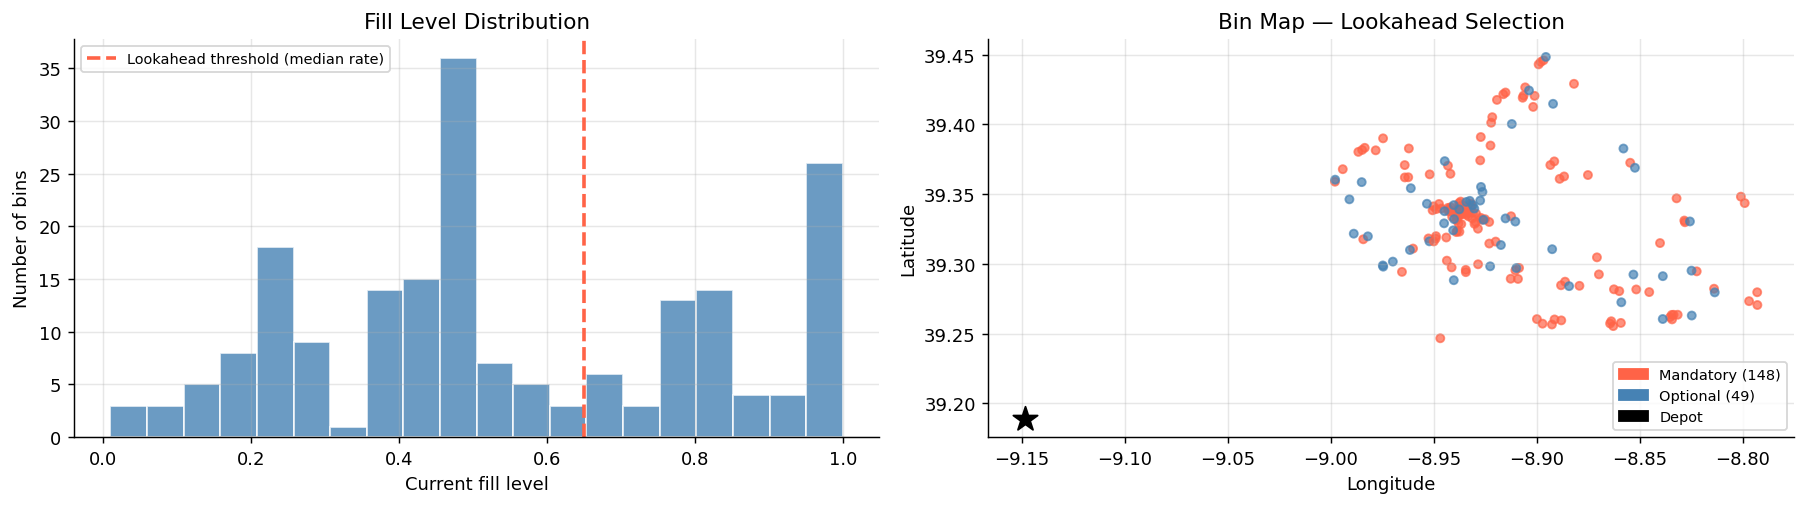

In [7]:
# ── Lookahead must-go selection ───────────────────────────────────────────────
sel_ctx = SelectionContext(
    bin_ids            = np.arange(len(bins_df), dtype=np.int32),
    current_fill       = (bins_df['fill_current'].values * 100).astype(np.float64),
    accumulation_rates = bins_df['accum_rate_pct_day'].values.astype(np.float64),
    current_collection_day = 0,
)

selected_1based, _ = LookaheadSelection().select_bins(sel_ctx)

if not selected_1based:
    raise ValueError('LookaheadSelection returned no bins. Check fill levels and accumulation rates.')

selected_rows = [bins_df.iloc[i - 1] for i in selected_1based]
selected_df   = pd.DataFrame(selected_rows).reset_index(drop=True)

print(f'LookaheadSelection selected : {len(selected_df)} mandatory bins')
print(f'Total mandatory kg          : {selected_df["kg_to_collect"].sum():.1f} kg')
print(f'Remaining fleet             : {len(bins_df) - len(selected_df)} optional bins')

# ── Sub-problem: full fleet ───────────────────────────────────────────────────
# Include the entire distance matrix so PG-CLNS can opportunistically visit
# non-mandatory bins when doing so improves the objective.
# Local indices equal global dm positions (identity mapping).
sub_idx = list(range(len(dm_ids)))   # [0, 1, ..., 258]  — depot + all 258 bins
sub_dm  = dm_np                      # full 259×259 matrix (no copy needed)

# Waste for every bin; non-mandatory bins with kg > 0 are candidates for
# opportunistic collection. Bins absent from bins_df default to 0.0 kg.
bins_kg = {int(row['bin_id']): float(row['kg_to_collect']) for _, row in bins_df.iterrows()}
sub_wastes = {
    pos: bins_kg.get(int(dm_ids[pos]), 0.0)
    for pos in range(1, len(dm_ids))   # pos 0 is depot — excluded
}

# Only the LookaheadMustGo bins are mandatory; PG-CLNS guarantees all of them
# are visited and may add further bins when profitable.
mandatory_local = [id_to_pos[int(row['bin_id'])] for row in selected_rows]

# ── Visualisation ────────────────────────────────────────────────────────────
mask_selected = bins_df['bin_id'].isin(selected_df['bin_id'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(bins_df['fill_current'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(
    (100 - bins_df['accum_rate_pct_day'].median()) / 100, color='tomato', lw=2,
    linestyle='--', label='Lookahead threshold (median rate)',
)
axes[0].set_xlabel('Current fill level'); axes[0].set_ylabel('Number of bins')
axes[0].set_title('Fill Level Distribution'); axes[0].legend(fontsize=8)

colors_scatter = ['tomato' if s else 'steelblue' for s in mask_selected]
axes[1].scatter(bins_df['lon'], bins_df['lat'], c=colors_scatter, s=20, alpha=0.7)
axes[1].scatter([depot_lon], [depot_lat], marker='*', c='black', s=200, zorder=5)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].set_title('Bin Map — Lookahead Selection')
axes[1].legend(handles=[
    mpatches.Patch(color='tomato',    label=f'Mandatory ({len(selected_df)})'),
    mpatches.Patch(color='steelblue', label=f'Optional ({(~mask_selected).sum()})'),
    mpatches.Patch(color='black',     label='Depot'),
], fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

---
## 4 · PG-CLNS Route Construction

In [8]:
print(f'Running PG-CLNS over {len(mandatory_local)} bins with capacity {VEHICLE_CAPACITY} kg/trip …')

solver = PGCLNSSolver(
    dist_matrix     = sub_dm,
    wastes          = sub_wastes,
    capacity        = VEHICLE_CAPACITY,
    R               = REVENUE_PER_KG,
    C               = COST_PER_KM,
    params          = PGCLNS_PARAMS,
    mandatory_nodes = mandatory_local,
    seed            = SEED,
)

t0 = time.perf_counter()
routes, pg_profit, pg_cost = solver.solve()
t_solve = time.perf_counter() - t0

# routes: List[List[int]] — each inner list is a single trip (local 1-based indices, no depot)
n_trips    = len(routes)
total_bins = sum(len(r) for r in routes)

print(f'PG-CLNS solved in {t_solve:.2f}s')
print(f'Trips generated   : {n_trips}')
print(f'Bins covered      : {total_bins} / {len(mandatory_local)}')
print(f'Reported profit   : {pg_profit:.2f} €')
print(f'Reported cost     : {pg_cost:.2f} km')
for i, route in enumerate(routes, 1):
    trip_kg = sum(sub_wastes.get(n, 0) for n in route)
    trip_km = get_route_cost(sub_dm, [0] + route + [0])
    print(f'  Trip {i}: {len(route)} stops, {trip_kg:.1f} kg, {trip_km:.2f} km')

Running PG-CLNS over 148 bins with capacity 3500.0 kg/trip …


PG-CLNS solved in 77.37s
Trips generated   : 2
Bins covered      : 197 / 148
Reported profit   : 4188.55 €
Reported cost     : 340.45 km
  Trip 1: 109 stops, 2682.8 kg, 196.05 km
  Trip 2: 88 stops, 1846.2 kg, 144.40 km


---
## 5 · Results & KPIs

In [9]:
# Build per-trip DataFrames with actual bin IDs and global distances
trip_records = []
for trip_num, route in enumerate(routes, 1):
    trip_km   = get_route_cost(sub_dm, [0] + route + [0])
    trip_kg   = sum(sub_wastes.get(n, 0) for n in route)
    trip_bins = [dm_ids[sub_idx[local_i]] for local_i in route]  # actual bin IDs
    trip_records.append({
        'trip'   : trip_num,
        'n_stops': len(route),
        'kg'     : round(trip_kg, 1),
        'km'     : round(trip_km, 2),
        'kg/km'  : round(trip_kg / trip_km, 3) if trip_km > 0 else 0.0,
        'bin_ids': trip_bins,
    })

trips_df = pd.DataFrame(trip_records)
print('=== Per-Trip Summary ===')
display(trips_df[['trip', 'n_stops', 'kg', 'km', 'kg/km']])

# Flat route: all trips stitched as depot-separated sequence
flat_route_global = []  # bin IDs in visit order (depot=0 between trips)
for rec in trip_records:
    flat_route_global += [0] + rec['bin_ids']
flat_route_global += [0]

=== Per-Trip Summary ===


,trip,n_stops,kg,km,kg/km
0,1,109,2682.8,196.05,13.684
1,2,88,1846.2,144.40,12.785


---
## 6 · Day KPIs

In [10]:
total_km  = trips_df['km'].sum()
total_kg  = trips_df['kg'].sum()
total_col = int(trips_df['n_stops'].sum())
kg_per_km = total_kg / total_km if total_km > 0 else 0.0
net_profit = REVENUE_PER_KG * total_kg - COST_PER_KM * total_km

kpis = {
    'km'        : round(total_km, 2),
    'kg'        : round(total_kg, 2),
    'ncol'      : total_col,
    'trips'     : n_trips,
    'kg/km'     : round(kg_per_km, 3),
    'profit (€)': round(net_profit, 2),
}

kpis_df = pd.DataFrame([kpis]).T.rename(columns={0: 'value'})
print('=== Day KPIs ===')
display(kpis_df)

=== Day KPIs ===


,value
km,340.450
kg,4529.000
ncol,197.000
trips,2.000
kg/km,13.303
profit (€),4188.550


### 6.1 · Styled Per-Trip KPI Table

In [11]:
# ---------------------------------------------------------------------------
# Styling helpers
# ---------------------------------------------------------------------------

def style_maximize(s):
    """Styles the best (highest) value green and 2nd-best light-green."""
    ranks = s.rank(method='dense', ascending=False)
    return [
        'background-color: #2ecc71; color: black; font-weight: bold;' if r == 1
        else 'background-color: #a9dfbf; color: black; font-weight: bold;' if r == 2
        else ''
        for r in ranks
    ]


def style_minimize(s):
    """Styles the best (lowest) value green and 2nd-best light-green."""
    ranks = s.rank(method='dense', ascending=True)
    return [
        'background-color: #2ecc71; color: black; font-weight: bold;' if r == 1
        else 'background-color: #a9dfbf; color: black; font-weight: bold;' if r == 2
        else ''
        for r in ranks
    ]


# ---------------------------------------------------------------------------
# Build the per-trip KPI table
# ---------------------------------------------------------------------------

# Add profit per trip (uses the same constants defined earlier in the notebook)
trips_kpi = trips_df[['trip', 'n_stops', 'kg', 'km', 'kg/km']].copy()
trips_kpi['profit (\u20ac)'] = (
    REVENUE_PER_KG * trips_kpi['kg'] - COST_PER_KM * trips_kpi['km']
).round(2)

# Column classification
MAXIMIZE_COLS = ['kg', 'profit (\u20ac)', 'kg/km']   # higher is better
MINIMIZE_COLS = ['km', 'n_stops']                     # lower is better

# Apply styling only when there are >= 2 trips (ranking is meaningless otherwise)
styled = trips_kpi.style.set_caption('Per-Trip KPIs')

if len(trips_kpi) >= 2:
    for col in MAXIMIZE_COLS:
        if col in trips_kpi.columns:
            styled = styled.apply(style_maximize, subset=[col])
    for col in MINIMIZE_COLS:
        if col in trips_kpi.columns:
            styled = styled.apply(style_minimize, subset=[col])

styled = styled.format(
    {
        'kg'           : '{:.1f}',
        'km'           : '{:.2f}',
        'kg/km'        : '{:.3f}',
        'profit (\u20ac)': '{:.2f}',
    }
)

print('=== Per-Trip KPI Table ===')
display(styled)

=== Per-Trip KPI Table ===


,trip,n_stops,kg,km,kg/km,profit (€)
0,1,109,2682.8,196.05,13.684,2486.75
1,2,88,1846.2,144.40,12.785,1701.80


### 6.2 · Multi-Policy KPI Table

Detailed breakdown per route and per policy, matching the EVOX dashboard report format.  
To compare multiple policies add additional dicts to `policy_results` in the next cell before running the renderer.

In [12]:
# ── KPI data preparation ──────────────────────────────────────────────────────
#
# Bin classification per route:
#   Mandatory  – selected by LookaheadSelection (MustGo + LookAhead combined)
#   Optional   – visited by the route constructor but NOT by the selection policy
#
# "Not Collected" is PER-ROUTE: total bins minus bins visited by that specific trip.
# The Total row shows the global uncovered count (bins visited by no trip at all).

_mandatory_bin_ids = set(selected_df['bin_id'])
_all_collected_ids = {bid for rec in trip_records for bid in rec['bin_ids']}
_n_total_bins      = len(bins_df)


def _build_trip_kpi(rec: dict) -> dict:
    trip_ids   = set(rec['bin_ids'])
    n_mand     = len(trip_ids & _mandatory_bin_ids)
    n_opt      = len(trip_ids - _mandatory_bin_ids)
    n_not_col  = _n_total_bins - len(trip_ids)
    kg, km     = rec['kg'], rec['km']
    return {
        'rota_id'   : rec['trip'],
        'n_col'     : rec['n_stops'],
        'n_mandatory': n_mand,
        'n_optional': n_opt,
        'n_not_col' : n_not_col,
        'profit'    : round(REVENUE_PER_KG * kg - COST_PER_KM * km, 3),
        'km'        : km,
        'kg'        : kg,
        'km_kg'     : round(km / kg, 6) if kg > 0 else 0.0,
        'km_ton'    : round(km / (kg / 1000), 3) if kg > 0 else 0.0,
        'cap_pct'   : round(kg / VEHICLE_CAPACITY * 100, 2),
    }


def _build_total_kpi(trips_kpi: list) -> dict:
    tot_kg = sum(t['kg'] for t in trips_kpi)
    tot_km = sum(t['km'] for t in trips_kpi)
    return {
        'rota_id'    : 'Total',
        'n_col'      : sum(t['n_col']       for t in trips_kpi),
        'n_mandatory': sum(t['n_mandatory'] for t in trips_kpi),
        'n_optional' : sum(t['n_optional']  for t in trips_kpi),
        'n_not_col'  : _n_total_bins - len(_all_collected_ids),  # globally uncovered
        'profit'     : round(REVENUE_PER_KG * tot_kg - COST_PER_KM * tot_km, 3),
        'km'         : round(tot_km, 2),
        'kg'         : round(tot_kg, 1),
        'km_kg'      : round(tot_km / tot_kg, 6) if tot_kg > 0 else 0.0,
        'km_ton'     : round(tot_km / (tot_kg / 1000), 3) if tot_kg > 0 else 0.0,
        'cap_pct'    : round(tot_kg / VEHICLE_CAPACITY * 100, 2),
    }


_cur_trips_kpi = [_build_trip_kpi(r) for r in trip_records]

# ── policy_results ─────────────────────────────────────────────────────────────
# Extend this list with additional dicts to compare multiple solvers.
# Each dict: {'name': str, 'trips': [kpi_dict, ...], 'total': kpi_dict}
policy_results: List[dict] = [
    {
        'name' : 'Lookahead + PG-CLNS',
        'trips': _cur_trips_kpi,
        'total': _build_total_kpi(_cur_trips_kpi),
    }
]

print(f'policy_results: {len(policy_results)} policy/policies')
for p in policy_results:
    tot = p['total']
    print(f"  {p['name']:35s}  trips={len(p['trips'])}  "
          f"collected={tot['n_col']}  globally_uncovered={tot['n_not_col']}")

policy_results: 1 policy/policies
  Lookahead + PG-CLNS                  trips=2  collected=197  globally_uncovered=0


In [13]:
# ── Multi-policy KPI table renderer ───────────────────────────────────────────
from IPython.display import HTML as _HTML

# ── Colour palette (dark backgrounds + explicit white text → readable on both
#    light and dark Jupyter themes) ────────────────────────────────────────────
_PALETTES = [
    # (header_bg, route_even_bg, route_odd_bg, total_bg)   — text colour is set per layer
    ('#154360', '#d6eaf8', '#eaf2f8', '#1a5276'),   # blue
    ('#145a32', '#d5f5e3', '#eafaf1', '#1e8449'),   # green
    ('#6e2f1a', '#fdebd0', '#fef9e7', '#784212'),   # orange
    ('#4a235a', '#e8daef', '#f5eef8', '#6c3483'),   # purple
    ('#1b2631', '#d5d8dc', '#eaecee', '#2c3e50'),   # slate
]
_HDR_BG  = '#1a2e45'   # top header row
_HDR_FG  = '#ffffff'

# ── Column definitions: (data_key, header, format_fn) ─────────────────────────
_COLS = [
    ('n_col',       'Number<br>Collected',          lambda v: str(int(v))),
    ('n_mandatory', 'Number<br>Mandatory',          lambda v: str(int(v))),
    ('n_optional',  'Number<br>Optionals',          lambda v: str(int(v))),
    ('n_not_col',   'Number Not<br>Collected',      lambda v: str(int(v))),
    ('profit',      'Profit<br>(€)',                lambda v: f'{v:,.3f}'),
    ('km',          'Distance<br>Travelled (km)',   lambda v: f'{v:,.2f}'),
    ('kg',          'Collected<br>Waste (kg)',      lambda v: f'{v:,.1f}'),
    ('km_kg',       'Travel Ratio<br>(km/kg)',      lambda v: f'{v:.6f}'),
    ('km_ton',      'Travel Ratio<br>(km/ton)',     lambda v: f'{v:,.3f}'),
    ('cap_pct',     'Capacity<br>Used (%)',         lambda v: f'{v:.2f}%'),
]

# ── Style builders ─────────────────────────────────────────────────────────────
_FONT = 'font-family:Segoe UI,Arial,sans-serif; font-size:12px;'
_PAD  = 'padding:6px 10px;'
_BDR  = 'border:1px solid #7f8c8d;'
_CENT = 'text-align:center; vertical-align:middle;'


def _cell(tag, txt, bg, fg, bold=False, rowspan=1, extra=''):
    fw  = 'font-weight:bold;' if bold else ''
    rs  = f' rowspan="{rowspan}"' if rowspan > 1 else ''
    s   = f'{_FONT}{_PAD}{_BDR}{_CENT} background:{bg}; color:{fg}; {fw} {extra}'
    return f'<{tag}{rs} style="{s}">{txt}</{tag}>'


def render_policy_kpi_table(results: list) -> str:
    out = [
        '<div style="overflow-x:auto;">',
        '<table style="border-collapse:collapse; width:100%; '
        'table-layout:auto; white-space:nowrap;">',
    ]

    # ── Header row ─────────────────────────────────────────────────────────────
    out.append('<thead><tr>')
    for hdr, w in [
        ('Algorithm',  'min-width:140px;'),
        ('Route ID',   'min-width:60px;'),
    ]:
        out.append(_cell('th', hdr, _HDR_BG, _HDR_FG, bold=True, extra=w))
    for _, hdr, _ in _COLS:
        out.append(_cell('th', hdr, _HDR_BG, _HDR_FG, bold=True))
    out.append('</tr></thead><tbody>')

    # ── Policy blocks ──────────────────────────────────────────────────────────
    for ai, policy in enumerate(results):
        trips   = policy['trips']
        total   = policy['total']
        n_rows  = len(trips) + 1        # trip rows + total row
        pal     = _PALETTES[ai % len(_PALETTES)]
        algo_bg, even_bg, odd_bg, tot_bg = pal
        # Algorithm name and total row use white text (dark backgrounds)
        # Route rows use near-black text on light backgrounds
        algo_fg, route_fg, tot_fg = '#ffffff', '#1a1a2e', '#ffffff'

        for ti, trip in enumerate(trips):
            r_bg = even_bg if ti % 2 == 0 else odd_bg
            out.append('<tr>')

            # Algorithm name — merged cell spanning all trip rows + total row
            if ti == 0:
                out.append(_cell(
                    'td', policy['name'], algo_bg, algo_fg,
                    bold=True, rowspan=n_rows,
                    extra='min-width:140px;',
                ))

            # Route number
            out.append(_cell('td', str(trip['rota_id']), r_bg, route_fg))

            # Data columns
            for key, _, fmt in _COLS:
                out.append(_cell('td', fmt(trip[key]), r_bg, route_fg))

            out.append('</tr>')

        # ── Total row ──────────────────────────────────────────────────────────
        out.append('<tr>')
        out.append(_cell('td', 'Total', tot_bg, tot_fg, bold=True))
        for key, _, fmt in _COLS:
            out.append(_cell('td', fmt(total[key]), tot_bg, tot_fg, bold=True))
        out.append('</tr>')

    out.append('</tbody></table></div>')
    return ''.join(out)


print('=== Multi-Policy KPI Table ===')
display(_HTML(render_policy_kpi_table(policy_results)))

=== Multi-Policy KPI Table ===


In [14]:
# Bin-level breakdown across all trips
_bins_lookup = bins_df.set_index('bin_id')   # fast lookup by bin_id

detail_rows = []
global_stop = 0
for rec in trip_records:
    cum_km = 0.0
    prev_dm_pos = 0  # depot
    for bin_id in rec['bin_ids']:
        global_stop += 1
        dm_pos   = id_to_pos[bin_id]
        cum_km  += sub_dm[sub_idx.index(prev_dm_pos), sub_idx.index(dm_pos)]
        bin_row  = _bins_lookup.loc[bin_id] if bin_id in _bins_lookup.index else None
        detail_rows.append({
            'trip'              : rec['trip'],
            'stop'              : global_stop,
            'bin_id'            : bin_id,
            'fill_current_pct'  : round(float(bin_row['fill_current']) * 100, 1) if bin_row is not None else None,
            'kg_to_collect'     : float(bin_row['kg_to_collect']) if bin_row is not None else 0.0,
            'days_until_overflow': (
                float(bin_row['days_until_overflow'])
                if bin_row is not None and pd.notna(bin_row['days_until_overflow'])
                else None
            ),
            'cum_km'            : round(cum_km, 2),
        })
        prev_dm_pos = dm_pos

route_detail = pd.DataFrame(detail_rows)
print(f'Optimised route — {len(route_detail)} stops across {n_trips} trips')
display(route_detail[['trip','stop','bin_id','fill_current_pct',
                       'kg_to_collect','days_until_overflow','cum_km']].to_string(index=False))

Optimised route — 197 stops across 2 trips


' trip  stop  bin_id  fill_current_pct  kg_to_collect  days_until_overflow  cum_km\n    1     1    5656              84.0           33.6             0.457143   27.96\n    1     2    3563              43.0           17.2             1.628571   34.43\n    1     3    1433              95.0           38.0             0.142857   35.13\n    1     4     347              49.0           19.6             1.457143   35.56\n    1     5    7653              43.0           17.2             1.628571   36.03\n    1     6    2350              77.0           30.8             0.657143   36.59\n    1     7    2726              55.0           22.0             1.285714   38.99\n    1     8    9766              40.0           16.0             1.714286   39.18\n    1     9    3630              38.0           15.2             1.771429   39.68\n    1    10    2069              99.0           39.6             0.028571   40.17\n    1    11    2211              19.0            7.6             2.314286   42.23\n   

---
## 7 · Route Visualisation

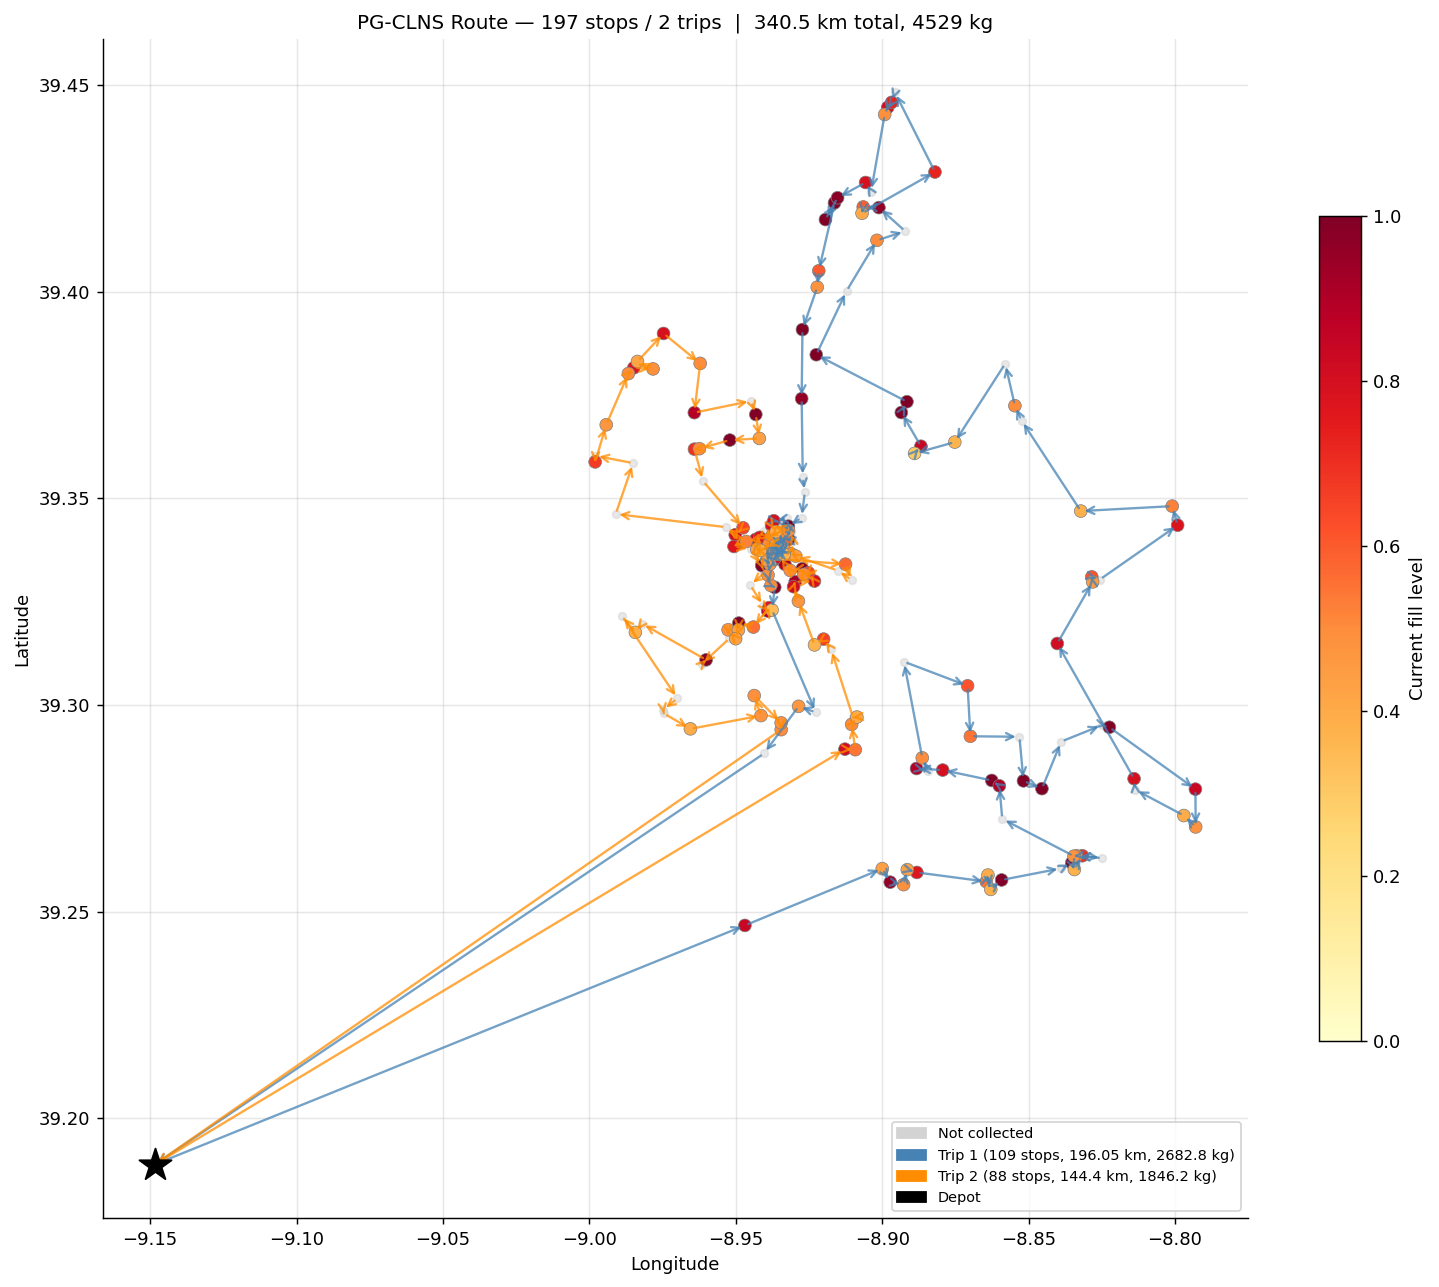

In [15]:
# Build lat/lon lookup
coords: Dict[int, Tuple[float, float]] = {
    int(row['bin_id']): (float(row['lat']), float(row['lon']))
    for _, row in bins_df.iterrows()
    if pd.notna(row['lat'])
}
coords[0] = (depot_lat, depot_lon)

TRIP_COLORS = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato',
               'mediumpurple', 'saddlebrown', 'deeppink', 'teal']

fig, ax = plt.subplots(figsize=(12, 10))

# Background bins not collected
not_sel = bins_df[~mask_selected]
ax.scatter(not_sel['lon'], not_sel['lat'],
           c='lightgrey', s=18, alpha=0.5, label='Not collected', zorder=2)

# Selected bins coloured by fill level
sc = ax.scatter(
    selected_df['lon'], selected_df['lat'],
    c=selected_df['fill_current'], cmap='YlOrRd', vmin=0, vmax=1,
    s=50, zorder=3, edgecolors='grey', linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label='Current fill level', shrink=0.7)

# Depot
ax.scatter([depot_lon], [depot_lat], marker='*', c='black', s=350, zorder=6)

# Draw each trip with its own colour
legend_patches = [mpatches.Patch(color='lightgrey', label='Not collected')]
for rec in trip_records:
    color = TRIP_COLORS[(rec['trip'] - 1) % len(TRIP_COLORS)]
    full_trip = [0] + rec['bin_ids'] + [0]
    for a_id, b_id in zip(full_trip[:-1], full_trip[1:]):
        if a_id in coords and b_id in coords:
            a_lat, a_lon = coords[a_id]
            b_lat, b_lon = coords[b_id]
            ax.annotate(
                '', xy=(b_lon, b_lat), xytext=(a_lon, a_lat),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3, alpha=0.75),
            )
    legend_patches.append(
        mpatches.Patch(color=color,
                       label=f'Trip {rec["trip"]} ({rec["n_stops"]} stops, {rec["km"]} km, {rec["kg"]} kg)')
    )

legend_patches.append(mpatches.Patch(color='black', label='Depot'))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    f'PG-CLNS Route — {total_col} stops / {n_trips} trips  |  '
    f'{total_km:.1f} km total, {total_kg:.0f} kg',
    fontsize=11,
)
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

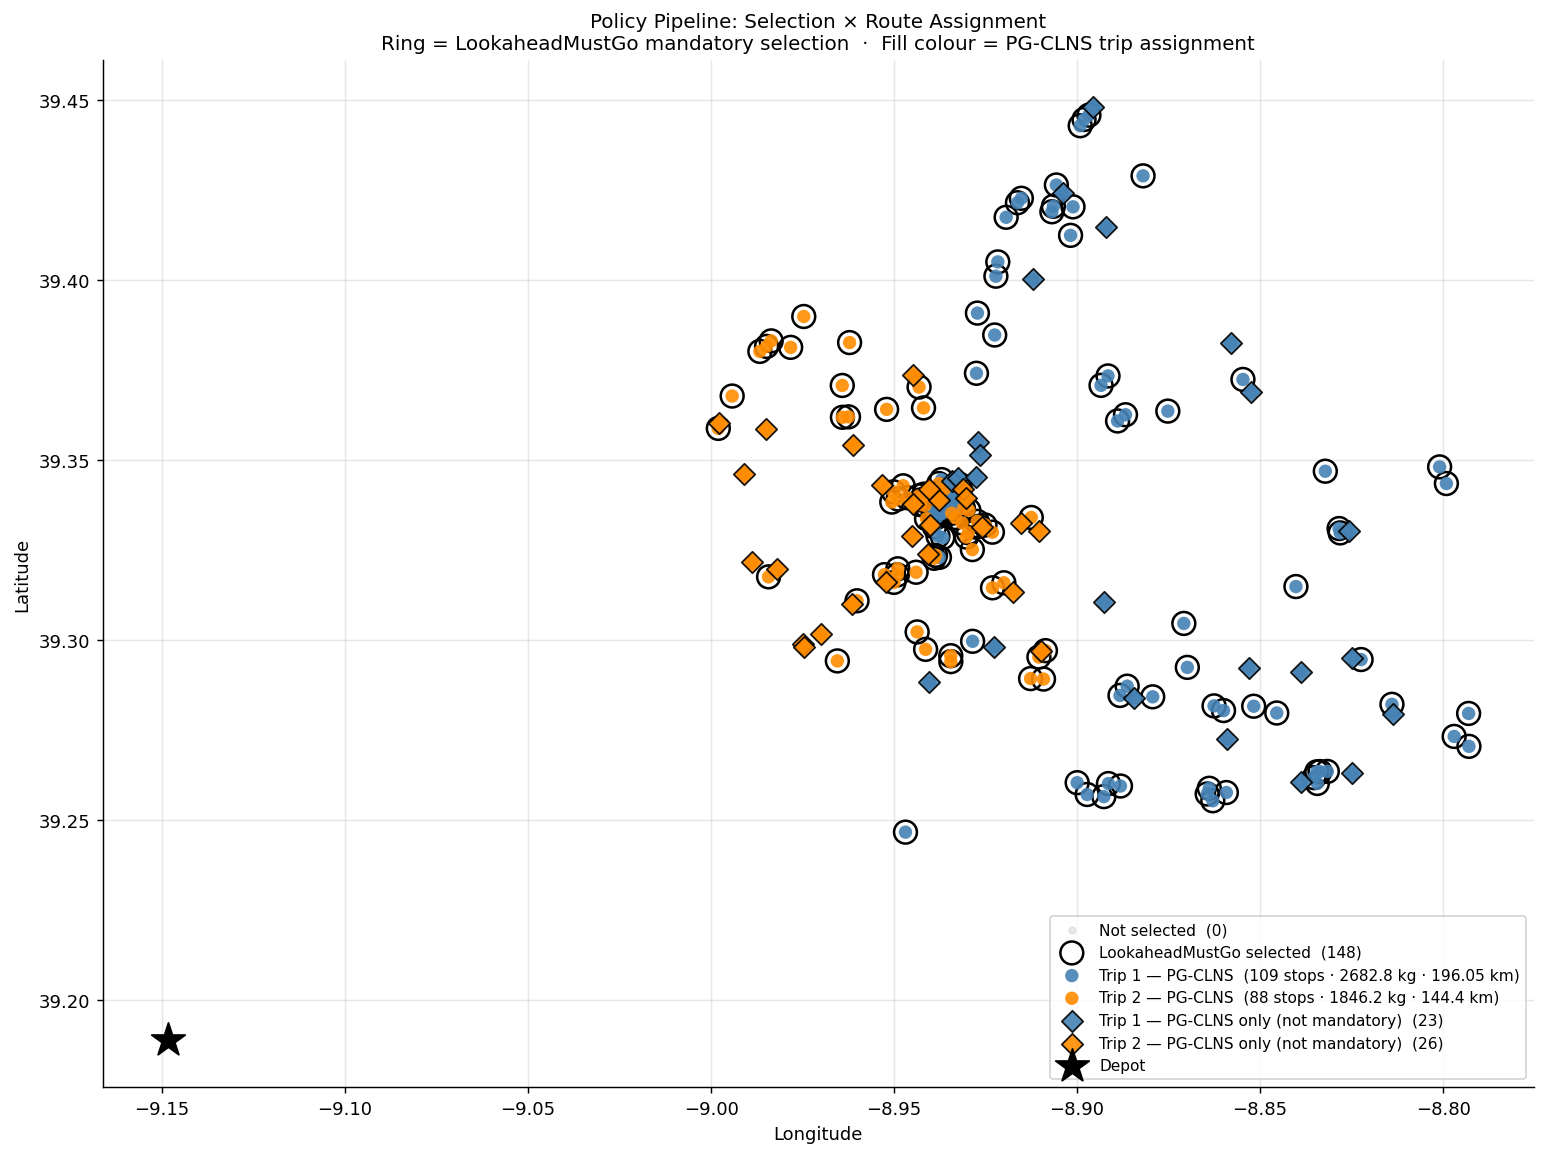

In [16]:
# ── Selection stage vs route assignment ──────────────────────────────────────
# Build bin_id → trip_number lookup from the route constructor output
trip_bin_map: Dict[int, int] = {}
for rec in trip_records:
    for bid in rec['bin_ids']:
        trip_bin_map[bid] = rec['trip']

# Bins chosen by LookaheadSelection but absent from all routes (edge case)
unrouted_ids = set(selected_df['bin_id']) - set(trip_bin_map.keys())

# Bins placed in a route by PG-CLNS but NOT flagged by mandatory selection
# (would appear if the solver adds opportunistic stops beyond mandatory_nodes)
constructor_only_ids = set(trip_bin_map.keys()) - set(selected_df['bin_id'])

fig, ax = plt.subplots(figsize=(12, 9))

# ── Layer 1: bins not touched by either stage ─────────────────────────────────
not_sel = bins_df[~mask_selected & ~bins_df['bin_id'].isin(constructor_only_ids)]
ax.scatter(
    not_sel['lon'], not_sel['lat'],
    c='lightgrey', s=14, alpha=0.5, zorder=2,
    label=f'Not selected  ({len(not_sel)})',
)

# ── Layer 2: mandatory-selection ring (LookaheadMustGo) ───────────────────────
# A hollow ring is drawn around every bin the mandatory selector flagged.
# Applies to both in-route and unrouted mandatory bins.
all_mandatory = selected_df.copy()
ax.scatter(
    all_mandatory['lon'], all_mandatory['lat'],
    facecolors='none', edgecolors='black', linewidths=1.4,
    s=160, zorder=3,
    label=f'LookaheadMustGo selected  ({len(all_mandatory)})',
)

# ── Layer 3: route-constructor fill (PG-CLNS) ─────────────────────────────────
# A solid filled dot inside each ring shows which trip PG-CLNS assigned the bin to.
for rec in trip_records:
    trip_num = rec['trip']
    color    = TRIP_COLORS[(trip_num - 1) % len(TRIP_COLORS)]
    trip_ids = set(rec['bin_ids'])
    trip_pts = bins_df[bins_df['bin_id'].isin(trip_ids)]
    ax.scatter(
        trip_pts['lon'], trip_pts['lat'],
        c=color, s=55, alpha=0.9, zorder=4, edgecolors='none',
        label=(
            f'Trip {trip_num} — PG-CLNS  '
            f'({rec["n_stops"]} stops · {rec["kg"]} kg · {rec["km"]} km)'
        ),
    )

# ── Layer 4: constructor-only bins (opportunistic, not mandatory) ──────────────
if constructor_only_ids:
    con_pts = bins_df[bins_df['bin_id'].isin(constructor_only_ids)]
    trip_num_map = {bid: trip_bin_map[bid] for bid in constructor_only_ids}
    for trip_num in sorted(set(trip_num_map.values())):
        color   = TRIP_COLORS[(trip_num - 1) % len(TRIP_COLORS)]
        sub_ids = {b for b, t in trip_num_map.items() if t == trip_num}
        sub_pts = con_pts[con_pts['bin_id'].isin(sub_ids)]
        ax.scatter(
            sub_pts['lon'], sub_pts['lat'],
            c=color, marker='D', s=70, alpha=0.9, zorder=4, edgecolors='black', linewidths=1.0,
            label=f'Trip {trip_num} — PG-CLNS only (not mandatory)  ({len(sub_pts)})',
        )

# ── Layer 5: mandatory bins the solver failed to route ───────────────────────
if unrouted_ids:
    unr_pts = bins_df[bins_df['bin_id'].isin(unrouted_ids)]
    ax.scatter(
        unr_pts['lon'], unr_pts['lat'],
        c='red', s=90, marker='x', linewidths=2.5, zorder=5,
        label=f'Mandatory but not routed  ({len(unrouted_ids)})',
    )

# ── Depot ─────────────────────────────────────────────────────────────────────
ax.scatter([depot_lon], [depot_lat], marker='*', c='black', s=380, zorder=6, label='Depot')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    'Policy Pipeline: Selection × Route Assignment\n'
    'Ring = LookaheadMustGo mandatory selection  ·  Fill colour = PG-CLNS trip assignment',
    fontsize=11,
)
ax.legend(fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.show()

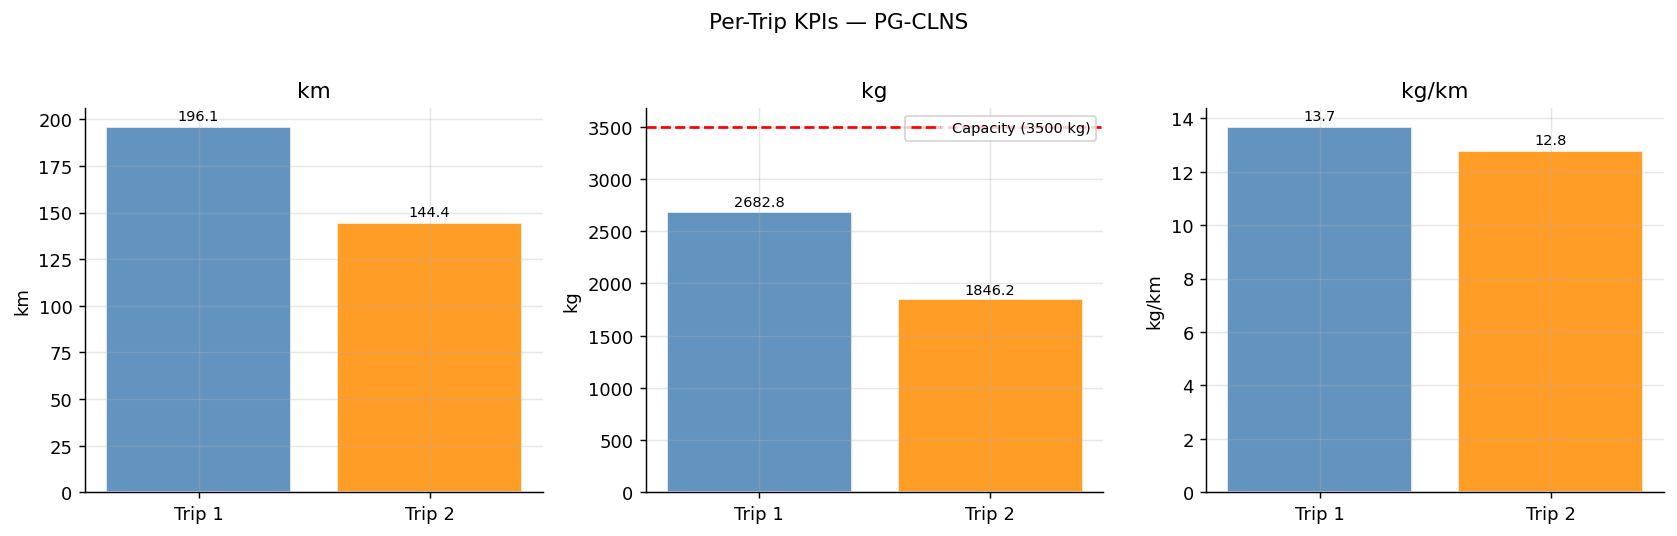

In [17]:
# ── Per-trip KPI bar chart ───────────────────────────────────────────────────
metrics_to_plot = ['km', 'kg', 'kg/km']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(13, 4))

trip_labels = [f'Trip {r["trip"]}' for r in trip_records]
colors = [TRIP_COLORS[(r['trip'] - 1) % len(TRIP_COLORS)] for r in trip_records]

for ax, metric in zip(axes, metrics_to_plot):
    values = [r[metric] for r in trip_records]
    bars = ax.bar(trip_labels, values, color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    if len(trip_labels) > 4:
        ax.set_xticklabels(trip_labels, rotation=30, ha='right', fontsize=8)

# Add capacity reference line to kg plot
axes[1].axhline(VEHICLE_CAPACITY, color='red', lw=1.5, linestyle='--',
                label=f'Capacity ({VEHICLE_CAPACITY:.0f} kg)')
axes[1].legend(fontsize=8)

plt.suptitle('Per-Trip KPIs — PG-CLNS', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

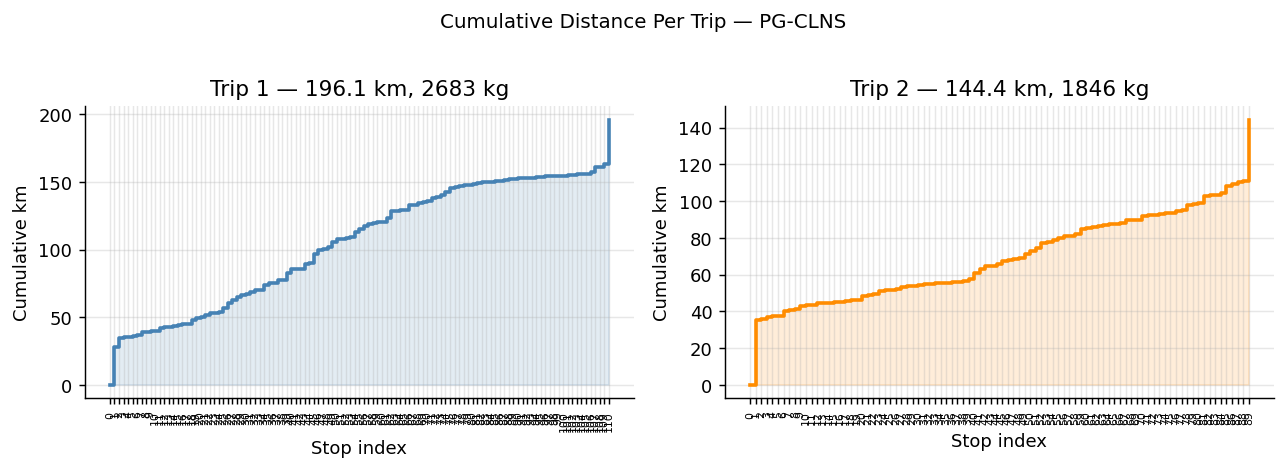

In [18]:
# ── Cumulative distance per trip ─────────────────────────────────────────────
fig, axes = plt.subplots(1, n_trips, figsize=(max(6, 5 * n_trips), 3.5), squeeze=False)

for ax, rec in zip(axes[0], trip_records):
    color = TRIP_COLORS[(rec['trip'] - 1) % len(TRIP_COLORS)]
    route_local = routes[rec['trip'] - 1]
    trip_seq    = [0] + route_local + [0]

    cum = [0.0]
    for a, b in zip(trip_seq[:-1], trip_seq[1:]):
        cum.append(cum[-1] + sub_dm[a, b])

    ax.step(range(len(cum)), cum, color=color, lw=2, where='post')
    ax.fill_between(range(len(cum)), cum, alpha=0.15, color=color, step='post')
    ax.set_title(f'Trip {rec["trip"]} — {rec["km"]:.1f} km, {rec["kg"]:.0f} kg')
    ax.set_xlabel('Stop index')
    ax.set_ylabel('Cumulative km')
    ax.set_xticks(range(len(cum)))
    ax.set_xticklabels(range(len(cum)), fontsize=6, rotation=90)

plt.suptitle('Cumulative Distance Per Trip — PG-CLNS', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 8 · Fill-Level Forecast for Non-Collected Bins

Non-collected bins        : 49
  Overflow within 1 day   : 0
  Overflow within 2–3 days: 43


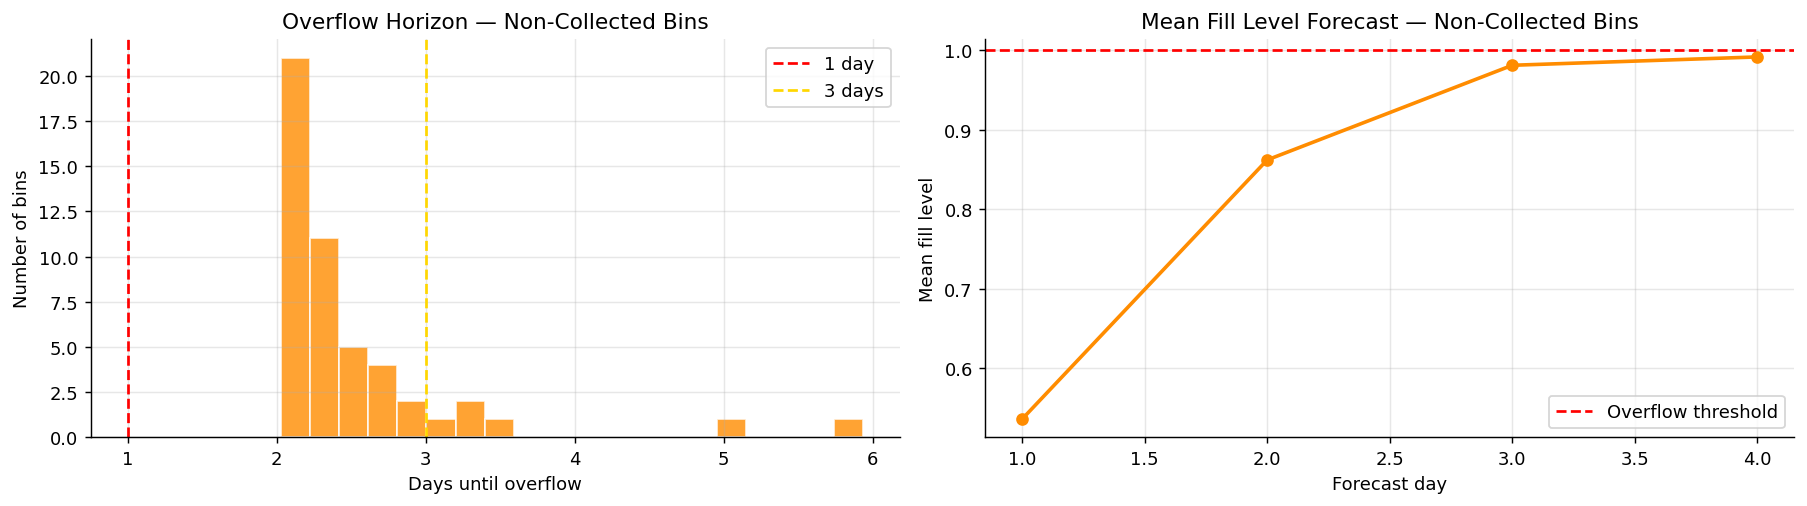

In [19]:
# Bins not collected today — show predicted overflow timeline
not_collected_df = bins_df[~mask_selected].copy()
not_collected_df = not_collected_df[not_collected_df['days_until_overflow'].notna()]

overflow_1d = not_collected_df[not_collected_df['days_until_overflow'] <= 1]
overflow_3d = not_collected_df[
    (not_collected_df['days_until_overflow'] > 1) &
    (not_collected_df['days_until_overflow'] <= 3)
]

print(f'Non-collected bins        : {len(not_collected_df)}')
print(f'  Overflow within 1 day   : {len(overflow_1d)}')
print(f'  Overflow within 2–3 days: {len(overflow_3d)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

days_vals = not_collected_df['days_until_overflow'].clip(upper=30)
axes[0].hist(days_vals, bins=20, color='darkorange', alpha=0.8, edgecolor='white')
axes[0].axvline(1, color='red', lw=1.5, linestyle='--', label='1 day')
axes[0].axvline(3, color='gold', lw=1.5, linestyle='--', label='3 days')
axes[0].set_xlabel('Days until overflow'); axes[0].set_ylabel('Number of bins')
axes[0].set_title('Overflow Horizon — Non-Collected Bins')
axes[0].legend()

day_cols = ['fill_day1', 'fill_day2', 'fill_day3', 'fill_day4']
available_cols = [c for c in day_cols if c in not_collected_df.columns]
if available_cols:
    means = not_collected_df[available_cols].mean()
    days  = [1, 2, 3, 4][:len(available_cols)]
    axes[1].plot(days, means.values, marker='o', color='darkorange', lw=2)
    axes[1].axhline(1.0, color='red', lw=1.5, linestyle='--', label='Overflow threshold')
    axes[1].set_xlabel('Forecast day'); axes[1].set_ylabel('Mean fill level')
    axes[1].set_title('Mean Fill Level Forecast — Non-Collected Bins')
    axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9 · Summary

In [20]:
print('=' * 58)
print('  WSmart+ Route — Single-Day Optimization Summary')
print('=' * 58)
print(f'  Source          : {_source_label}')
print(f'  Total bins      : {len(bins_df)}')
print(f'  Selection       : LookaheadMustGo')
print(f'  Bins selected   : {len(selected_df)}  ({len(selected_df)/len(bins_df)*100:.1f}% of fleet)')
print(f'  Solver          : PG-CLNS (no route improver)')
print(f'  Vehicle cap.    : {VEHICLE_CAPACITY:.0f} kg/trip')
print()
print(f'  Trips           : {n_trips}')
print(f'  Total distance  : {total_km:>8.2f} km')
print(f'  Waste collected : {total_kg:>8.1f} kg')
print(f'  Efficiency      : {kg_per_km:>8.3f} kg/km')
print(f'  Profit (net)    : {net_profit:>8.2f} €')
print(f'  Solve time      : {t_solve:.2f}s')
print()
for rec in trip_records:
    print(f'  Trip {rec["trip"]:>2}: {rec["n_stops"]:>3} stops, '
          f'{rec["kg"]:>7.1f} kg / {VEHICLE_CAPACITY:.0f} kg cap, '
          f'{rec["km"]:>7.2f} km')
print('=' * 58)

  WSmart+ Route — Single-Day Optimization Summary
  Source          : dashboard_riomaior_20260622_104546.html
  Total bins      : 197
  Selection       : LookaheadMustGo
  Bins selected   : 148  (75.1% of fleet)
  Solver          : PG-CLNS (no route improver)
  Vehicle cap.    : 3500 kg/trip

  Trips           : 2
  Total distance  :   340.45 km
  Waste collected :   4529.0 kg
  Efficiency      :   13.303 kg/km
  Profit (net)    :  4188.55 €
  Solve time      : 77.37s

  Trip  1: 109 stops,  2682.8 kg / 3500 kg cap,  196.05 km
  Trip  2:  88 stops,  1846.2 kg / 3500 kg cap,  144.40 km
